In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
from tokenizers import Tokenizer
from pathlib import Path
import numpy as np

In [40]:
@dataclass
class args:
    block_size = 128
    batch_size = 64
    embeddings_dims = 768
    attn_dropout = 0.1
    no_of_heads = 4
    dropout = 0.1
    epochs = 100
    max_lr = 2.5e-4
    no_of_decoder_layers = 12 
    weight_decay_optim = 0.1
    beta_1 = 0.9
    beta_2 = 0.95
    device = 'cuda'
    no_kv_heads = 2
    vocab_size = 2000


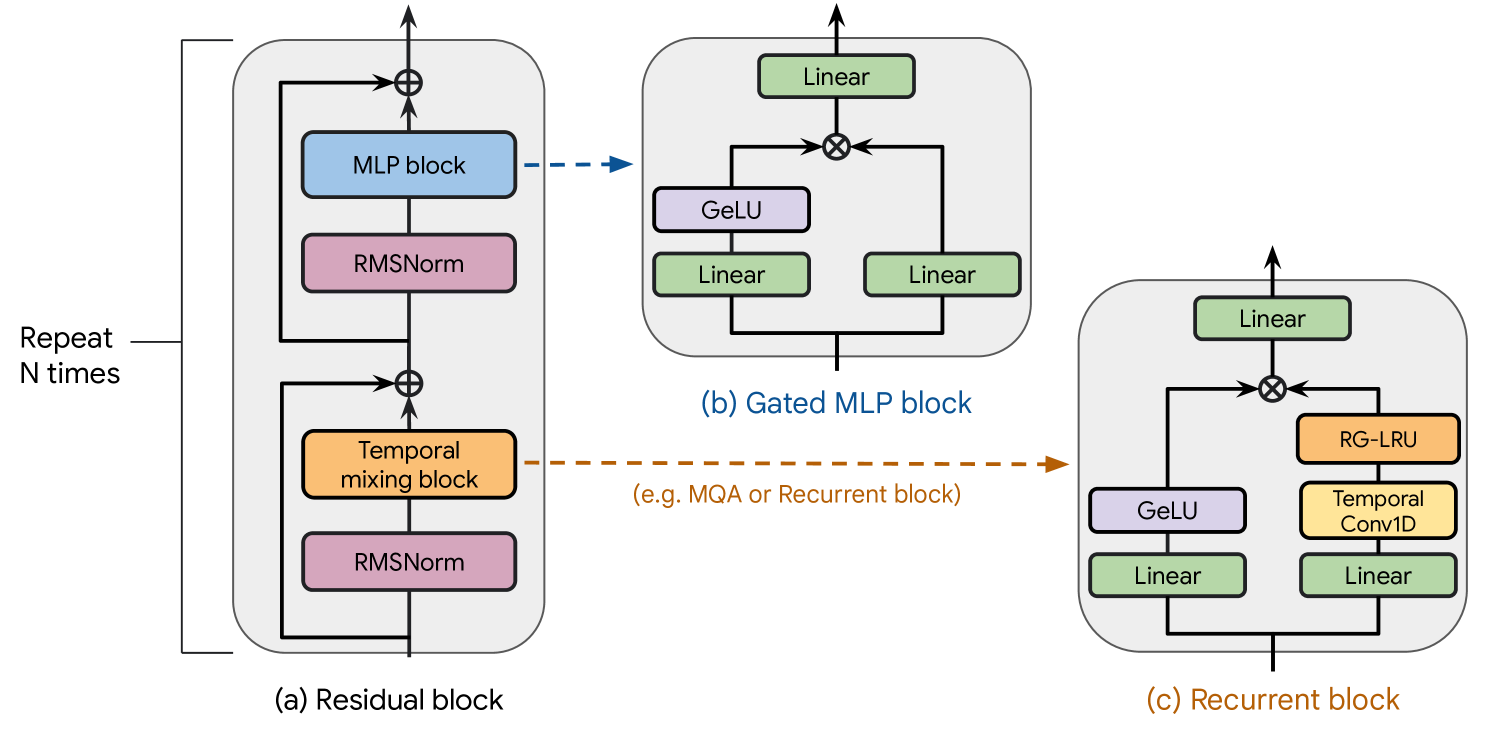

In [41]:
data_path = Path('data')
data_path.mkdir(exist_ok=True)

In [42]:
import os
import requests

# Download the dataset if it doesn't exist
os.makedirs('data', exist_ok=True)
file_path = 'data/input.txt'

if not os.path.exists(file_path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    r = requests.get(url)
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(r.text)

# Read the dataset
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

# Build the character-level vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

# Overwrite args.vocab_size with the actual vocabulary size
args.vocab_size = vocab_size

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
def encode_as_ids(s):
    return [stoi[c] for c in s]
def decode(l):
    return ''.join([itos[i] for i in l])


In [43]:
data = torch.tensor(encode_as_ids(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - args.block_size, (args.batch_size,))
    x = torch.stack([data[i:i+args.block_size] for i in ix])
    y = torch.stack([data[i+1:i+args.block_size+1] for i in ix])
    x, y = x.to(args.device), y.to(args.device)
    return x, y


In [44]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

class Normalization(nn.Module):
    def __init__(self, embeddings_dims: int = args.embeddings_dims):  
        super().__init__()
        self.rmsnorm_layer = RMSNorm(dim=embeddings_dims)
        
    def forward(self, x):    
        x = self.rmsnorm_layer(x)
        return x


In [45]:
class RotaryEmbeddings(nn.Module):
    def __init__(
        self,
        embeddings_dims: int = args.embeddings_dims,
        block_size: int = args.block_size,
        batch_size: int = args.batch_size
    ):
        super().__init__()
        self.embeddings_dims = embeddings_dims
        self.block_size = block_size
        self.batch_size = batch_size
        self.theta = 0  

    def init_matrix(self, seq_len):
        self.matrix = torch.zeros((seq_len, self.embeddings_dims, self.embeddings_dims), device=args.device, requires_grad=False)
        positions = torch.arange(seq_len, device=args.device).unsqueeze(1)
        theta = 10000 ** (-2 * (positions - 1) / self.embeddings_dims)
        angles = positions * theta
        
        cos_angles = torch.cos(angles)
        sin_angles = torch.sin(angles)
        
        indices = torch.arange(self.embeddings_dims, device=args.device)
        even_indices = indices[::2]
        odd_indices = indices[1::2]
        
        self.matrix[:, even_indices, even_indices] = cos_angles
        self.matrix[:, odd_indices, odd_indices] = sin_angles
        self.matrix[:, odd_indices, even_indices] = -sin_angles
        self.matrix[:, even_indices, odd_indices] = cos_angles
        
        return self.matrix

    def forward(self, x):
        if x > self.block_size:
            matrix = self.init_matrix(x)
            return matrix
        else:
            matrix = self.init_matrix(self.block_size)
            return matrix


In [46]:
class MQA(nn.Module):
    def __init__(
        self,
        embeddings_dims: int = args.embeddings_dims,
        block_size: int = args.block_size,
        no_of_kv_heads: int = args.no_kv_heads,
        no_of_heads: int = args.no_of_heads
    ):
        super().__init__()
        self.no_of_kv_heads = no_of_kv_heads
        self.no_of_q_heads = no_of_heads // no_of_kv_heads if no_of_kv_heads > 0 else 1
        self.head_size = embeddings_dims // self.no_of_q_heads
        self.rotary_matrix = RotaryEmbeddings(embeddings_dims=embeddings_dims)
        
        self.multi_query = nn.ModuleList([nn.Linear(in_features=embeddings_dims, out_features=embeddings_dims, device=args.device, bias=False) for _ in range(self.no_of_q_heads)])
        self.key = nn.Linear(in_features=embeddings_dims, out_features=embeddings_dims, device=args.device,  bias=False)
        self.value = nn.Linear(in_features=embeddings_dims, out_features=embeddings_dims, device=args.device, bias=False)
        self.dropout = nn.Dropout(p = args.attn_dropout)
        self.linear_layer = nn.Linear(in_features=embeddings_dims * self.no_of_q_heads, out_features=embeddings_dims, device=args.device, bias=False)
        
    def scaled_dot_product(self, q, k, v, block_size, matrix):
        masked = torch.tril(torch.ones((block_size, block_size), device=args.device, requires_grad=False))
        m = matrix[:block_size, :, :]
        rotary_query = m @ q.permute(1,2,0)
        rotary_key = m @ k.permute(1,2,0)
        weights = rotary_query.permute(2,0,1) @ rotary_key.permute(2,0,1).transpose(-2, -1)
        weights_masked = weights.masked_fill(masked == 0, float('-inf'))
        scaled_weights = weights_masked / (torch.sqrt(torch.tensor(k.shape[-1])))
        scaled_weights = F.softmax(scaled_weights, dim=-1)
        value = scaled_weights @ v
        out = self.dropout(value)
        return out
    
    def forward(self, x):
        batch, block_size, embeddings_dims = x.shape
        matrix = self.rotary_matrix(block_size)
        key = self.key(x)
        values = self.value(x)
        multi_query_concat = torch.cat([self.scaled_dot_product(query(x), key, values, block_size, matrix) for query in self.multi_query], dim=-1)
        linear_layer = self.linear_layer(multi_query_concat)
        out = self.dropout(linear_layer)
        return out


In [47]:
class GeGLU(nn.Module):
    def __init__(
        self,
        block_size: int = args.block_size,
        embeddings_dims: int = args.embeddings_dims
    ):
        super().__init__()
        hidden_dims = 4 * embeddings_dims
        self.linear_layer1 = nn.Linear(in_features=embeddings_dims, out_features=hidden_dims, device=args.device, bias=False)
        self.linear_layer2 = nn.Linear(in_features=embeddings_dims, out_features=hidden_dims, device=args.device, bias=False)
        self.linear_layer3 = nn.Linear(in_features=hidden_dims, out_features=embeddings_dims, device=args.device, bias=False)
        
    def forward(self, x):
        gelu_res = nn.functional.gelu(self.linear_layer1(x))
        x_V = self.linear_layer2(x)
        res = torch.mul(gelu_res, x_V)
        out = self.linear_layer3(res)
        return out


In [48]:
class FFN(nn.Module):
    def __init__(self,
                  embeddings_dims: int = args.embeddings_dims,
                  block_size: int = args.block_size,
                  vocab_size: int = args.vocab_size,
                   dropout = args.dropout
                 ):
        super().__init__()
        self.gglu = GeGLU(block_size=block_size, embeddings_dims=embeddings_dims)
        self.dropout = nn.Dropout(p = dropout)
        
    def forward(self, x):
        x = self.gglu(x)
        x = self.dropout(x)
        return x


In [49]:
class DecoderLayer(nn.Module):
    def __init__(self, 
                embeddings_dims: int = args.embeddings_dims,
                dropout = args.dropout,
                block_size: int = args.block_size,
                vocab_size: int = args.vocab_size,
                 ):
        super().__init__()
        self.feedforward_network = FFN(embeddings_dims=embeddings_dims, block_size=block_size, vocab_size=vocab_size, dropout=dropout)
        self.mqa = MQA(embeddings_dims=embeddings_dims, block_size=block_size, no_of_kv_heads=args.no_kv_heads, no_of_heads=args.no_of_heads)
        self.norm1 = Normalization(embeddings_dims=embeddings_dims)
        self.norm2 = Normalization(embeddings_dims=embeddings_dims)
        self.dropout = nn.Dropout(p = dropout)
        
    def forward(self, x):
        x = x + self.mqa(self.norm1(x))
        x = x + self.feedforward_network(self.norm2(x))
        return x


In [50]:
class Gemma(nn.Module):
    def __init__(self, 
                  embeddings_dims: int = args.embeddings_dims,
                  no_of_decoder_layers: int = args.no_of_decoder_layers,
                  block_size: int = args.block_size,
                  vocab_size: int = args.vocab_size,
                  dropout = args.dropout
                 ):
        super().__init__()
        self.embeddings = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embeddings_dims, device=args.device)
        self.decoder = nn.Sequential(*[DecoderLayer(embeddings_dims=embeddings_dims, block_size=block_size, vocab_size=vocab_size, dropout=dropout) for _ in range(no_of_decoder_layers)])
        self.linear_layer = nn.Linear(in_features=embeddings_dims, out_features=vocab_size, device=args.device)
        self.dropout = nn.Dropout(p = dropout)
        self.norm = Normalization(embeddings_dims)
        
    def forward(self, x):
        x = self.embeddings(x)
        x = self.dropout(x)
        x = self.decoder(x)
        x = self.norm(x)
        x = self.linear_layer(x)
        return x


In [58]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [52]:
args.device = device
model = Gemma(embeddings_dims=args.embeddings_dims, block_size=args.block_size, vocab_size=args.vocab_size, dropout=args.dropout)
model = model.to(args.device)

In [53]:
from torchinfo import summary

In [54]:
summary(model=model,)

Layer (type:depth-idx)                        Param #
Gemma                                         --
├─Embedding: 1-1                              49,920
├─Sequential: 1-2                             --
│    └─DecoderLayer: 2-1                      --
│    │    └─FFN: 3-1                          7,077,888
│    │    └─MQA: 3-2                          3,538,944
│    │    └─Normalization: 3-3                768
│    │    └─Normalization: 3-4                768
│    │    └─Dropout: 3-5                      --
│    └─DecoderLayer: 2-2                      --
│    │    └─FFN: 3-6                          7,077,888
│    │    └─MQA: 3-7                          3,538,944
│    │    └─Normalization: 3-8                768
│    │    └─Normalization: 3-9                768
│    │    └─Dropout: 3-10                     --
│    └─DecoderLayer: 2-3                      --
│    │    └─FFN: 3-11                         7,077,888
│    │    └─MQA: 3-12                         3,538,944
│    │    └─No

In [55]:
optimizer = torch.optim.AdamW(params=model.parameters(), lr=args.max_lr)

total_steps = 5000
eval_iters = 100

@torch.inference_mode()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            idx, targets = get_batch(split=split)
            logits = model(idx)
            batch_size, block_size, v_size = logits.shape
            logits = logits.view(batch_size*block_size, v_size) 
            targets = targets.contiguous().view(batch_size * block_size)
            loss = nn.functional.cross_entropy(logits, targets)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


In [ ]:
import os
from tqdm import tqdm
os.makedirs('weights', exist_ok=True)
model.train()
for step in tqdm(range(total_steps)):

    if (step  % eval_iters == 0 and step != 0) or step == total_steps - 1:
        losses = estimate_loss()
        print(f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        torch.save(model.state_dict(), 'weights/Gemma%d.pth' % (step))

    idx, targets = get_batch(split='train')
    logits = model(idx)
    batch_size, block_size, v_size = logits.shape
    logits = logits.view(batch_size*block_size, v_size)
    targets = targets.contiguous().view(batch_size * block_size)
    loss = nn.functional.cross_entropy(logits, targets)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


stopped after 3500 steps 

In [56]:
checkpoint_path = 'weights/Gemma3500.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=args.device))

model.eval()

@torch.inference_mode()
def generate(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        #cropping context to max block size
        idx_cond = idx[:, -args.block_size:]
        logits = model(idx_cond)
        logits = logits[:, -1, :] 
        probs = F.softmax(logits, dim=-1)
        #sample
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

start_str = "LORD:\n"
context = torch.tensor(encode_as_ids(start_str), dtype=torch.long, device=args.device).unsqueeze(0)
generated_seq = generate(model, context, max_new_tokens=200)

print(decode(generated_seq[0].tolist()))


/tmp/ipykernel_62166/866881738.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=args.device))


LORD:
There is my father, slain! O sweet Montague,
Either powerful army is despair: yet you
will have him much company, which stricks
So many soon sincer; nothing but so metone
Than any in that?
Have we no 


Late inference due to calculation of rotation matrix for every token in every layer 